REMEMBER
Valid date strings can be converted to datetime objects using to_datetime function or as part of read functions.
Datetime objects in pandas support calculations, logical operations and convenient date-related properties using the dt accessor.
A DatetimeIndex contains these date-related properties and supports convenient slicing.
Resample is a powerful method to change the frequency of a time series.

https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/09_timeseries.html

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [10]:
air_quality = pd.read_csv("https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_no2_long.csv")

In [11]:
air_quality = air_quality.rename(columns={"date.utc": "datetime"})

In [25]:
air_quality.head()

,city,country,datetime,location,parameter,value,unit,month
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6


In [26]:
air_quality.city.unique()

array(['Paris', 'Antwerpen', 'London'], dtype=object)

In [27]:
air_quality["datetime"] = pd.to_datetime(air_quality["datetime"])

In [28]:
air_quality["datetime"]

0      2019-06-21 00:00:00+00:00
1      2019-06-20 23:00:00+00:00
2      2019-06-20 22:00:00+00:00
3      2019-06-20 21:00:00+00:00
4      2019-06-20 20:00:00+00:00
                  ...           
2063   2019-05-07 06:00:00+00:00
2064   2019-05-07 04:00:00+00:00
2065   2019-05-07 03:00:00+00:00
2066   2019-05-07 02:00:00+00:00
2067   2019-05-07 01:00:00+00:00
Name: datetime, Length: 2068, dtype: datetime64[ns, UTC]

In [29]:
air_quality["datetime"].min(), air_quality["datetime"].max()

(Timestamp('2019-05-07 01:00:00+0000', tz='UTC'),
 Timestamp('2019-06-21 00:00:00+0000', tz='UTC'))

In [30]:
air_quality["datetime"].max() - air_quality["datetime"].min()

Timedelta('44 days 23:00:00')

In [31]:
air_quality["month"] = air_quality["datetime"].dt.month

In [32]:
air_quality.head()

,city,country,datetime,location,parameter,value,unit,month
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6


In [34]:
air_quality.groupby(
    [air_quality["datetime"].dt.weekday, "location"])["value"].mean()

datetime  location          
0         BETR801               27.875000
          FR04014               24.856250
          London Westminster    23.969697
1         BETR801               22.214286
          FR04014               30.999359
          London Westminster    24.885714
2         BETR801               21.125000
          FR04014               29.165753
          London Westminster    23.460432
3         BETR801               27.500000
          FR04014               28.600690
          London Westminster    24.780142
4         BETR801               28.400000
          FR04014               31.617986
          London Westminster    26.446809
5         BETR801               33.500000
          FR04014               25.266154
          London Westminster    24.977612
6         BETR801               21.896552
          FR04014               23.274306
          London Westminster    24.859155
Name: value, dtype: float64

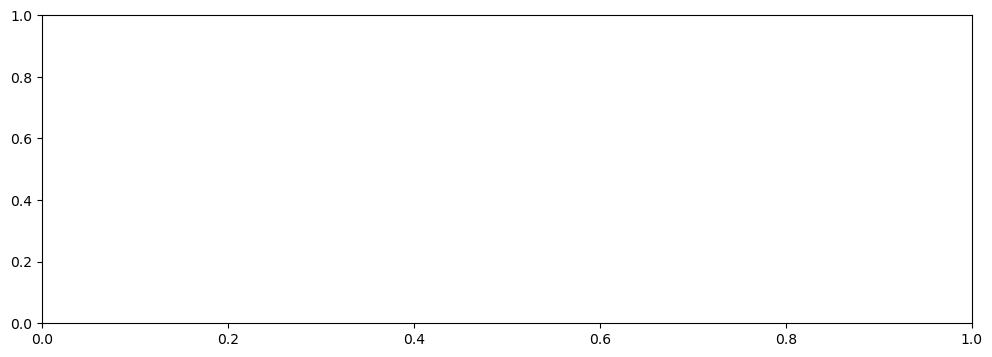

In [35]:
fig, axs = plt.subplots(figsize=(12, 4))

In [36]:
air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean().plot(
    kind='bar', rot=0, ax=axs
)

<Axes: xlabel='datetime'>

Text(0, 0.5, '$NO_2 (µg/m^3)$')

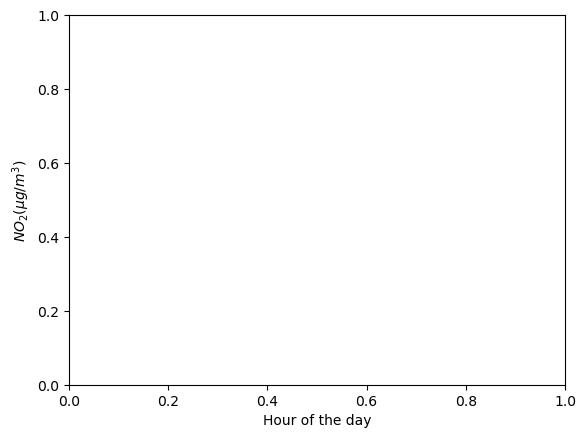

In [41]:
air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean().plot(
    kind='bar', rot=0, ax=axs
)
plt.xlabel("Hour of the day")  # custom x label using Matplotlib
plt.ylabel("$NO_2 (µg/m^3)$")

Text(0, 0.5, '$NO_2 (µg/m^3)$')

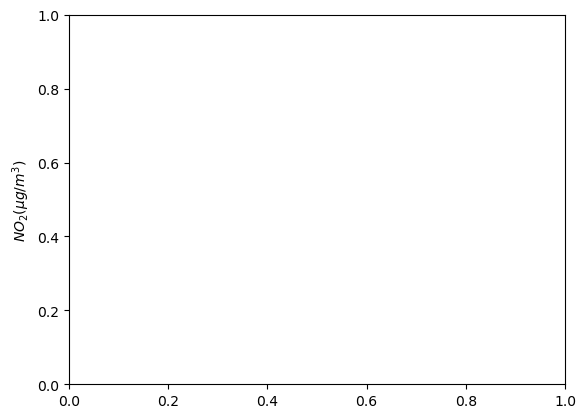

In [38]:
plt.ylabel("$NO_2 (µg/m^3)$")

Text(0, 0.5, '$NO_2 (µg/m^3)$')

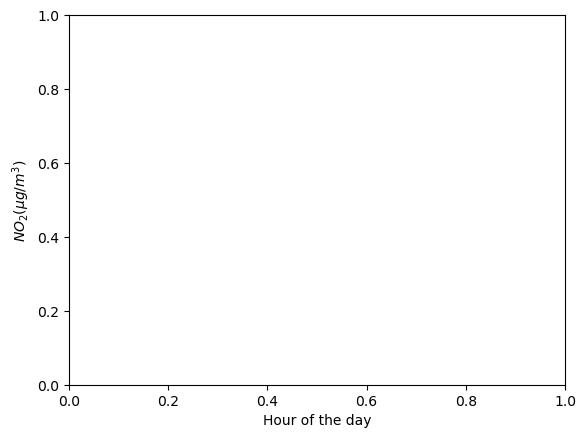

In [43]:
air_quality.head()
air_quality.groupby(
    [air_quality["datetime"].dt.weekday, "location"])["value"].mean()
air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean().plot(
    kind='bar', rot=0, ax=axs
)
plt.xlabel("Hour of the day")  # custom x label using Matplotlib
plt.ylabel("$NO_2 (µg/m^3)$")

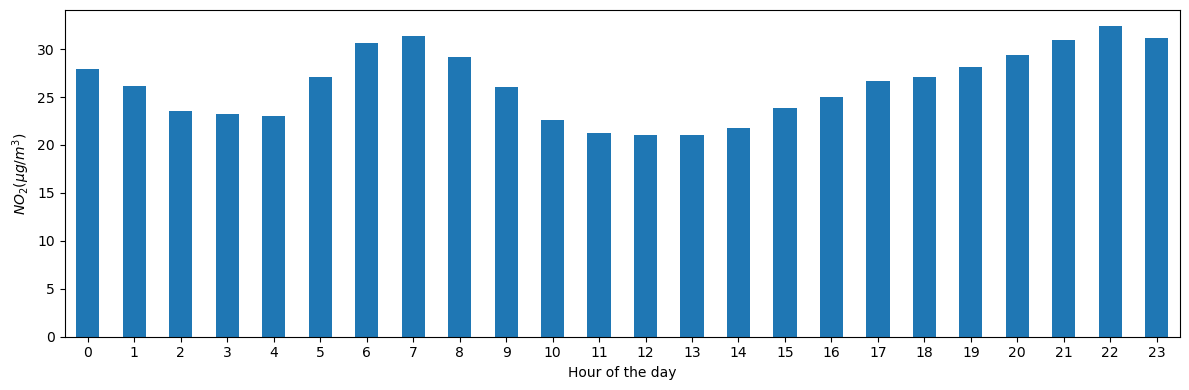

In [45]:
# Display the first few rows of the air_quality dataframe
air_quality.head()

# Calculate the mean value for each weekday and location combination
air_quality.groupby(
    [air_quality["datetime"].dt.weekday, "location"])["value"].mean()

# Create a figure and axis for plotting
fig, axs = plt.subplots(figsize=(12, 4))

# Plot the mean NO2 values by hour of day as a bar chart
air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean().plot(
    kind='bar', rot=0, ax=axs
)
plt.xlabel("Hour of the day")  # custom x label using Matplotlib
plt.ylabel("$NO_2 (µg/m^3)$")  # y-axis label with scientific notation

# Display the plot
plt.tight_layout()
plt.show()

In [46]:
no_2 = air_quality.pivot(index="datetime", columns="location", values="value")

In [47]:
no_2.head()

location,BETR801,FR04014,London Westminster
datetime,,,
2019-05-07 01:00:00+00:00,50.5,25.0,23.0
2019-05-07 02:00:00+00:00,45.0,27.7,19.0
2019-05-07 03:00:00+00:00,NaN,50.4,19.0
2019-05-07 04:00:00+00:00,NaN,61.9,16.0
2019-05-07 05:00:00+00:00,NaN,72.4,NaN


In [48]:
no_2.index.year, no_2.index.weekday

(Index([2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019,
        ...
        2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019],
       dtype='int32', name='datetime', length=1033),
 Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        ...
        3, 3, 3, 3, 3, 3, 3, 3, 3, 4],
       dtype='int32', name='datetime', length=1033))

<Axes: xlabel='datetime'>

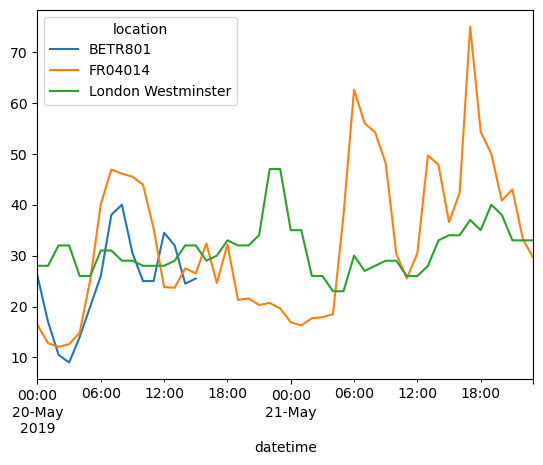

In [49]:
no_2["2019-05-20":"2019-05-21"].plot()

In [50]:
monthly_max = no_2.resample("ME").max()
monthly_max

location,BETR801,FR04014,London Westminster
datetime,,,
2019-05-31 00:00:00+00:00,74.5,97.0,97.0
2019-06-30 00:00:00+00:00,52.5,84.7,52.0


In [51]:
monthly_max.index.freq

<MonthEnd>

<Axes: xlabel='datetime'>

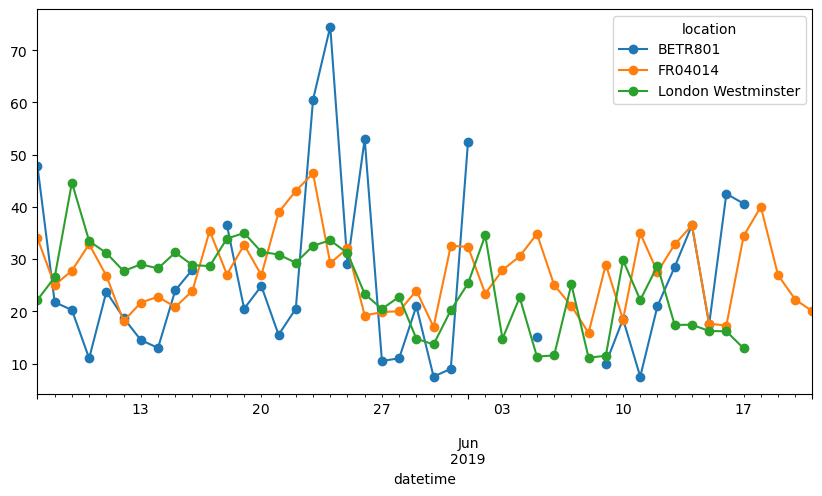

In [52]:
no_2.resample("D").mean().plot(style="-o", figsize=(10, 5))